# Phase 5: Data Preprocessing & ML Pipeline Preparation
**Objective:** To convert the validated geotechnical telemetry dataset into a machine-learning-ready matrix by engineering categorical encodings, feature normalization, outlier control, and class balancing strategies.

---

### 🎯 Core Engineering Objectives:
1. Preserve geotechnical realism while handling incomplete excavation records.
2. Convert categorical site descriptors into numerical tensors for ML ingestion.
3. Normalize heterogeneous IoT telemetry scales into a unified feature space.
4. Address severe target imbalance to prevent predictive bias toward failure states.
5. Produce a finalized tensor dataset for predictive excavation safety modeling.

In [8]:
# =========================================================
# PHASE 5.1 — PREPROCESSING INITIALIZATION
# =========================================================

# Create a working copy to preserve raw validated telemetry
import pandas as pd
from sklearn.preprocessing import StandardScaler
df = pd.read_csv("excavation_risk_dataset (2).csv")
print(df.head())
print(df.info())
df_processed = df.copy()

print("✅ Preprocessing Environment Initialized")
print(f"Working Dataset Shape: {df_processed.shape}")

# Quick Null Validation
print("\n--- NULL VALUE AUDIT ---")
display(df_processed.isnull().sum())

  Soil_Type  Soil_Moisture_%  Shear_Strength_kPa  Bearing_Capacity_kPa  \
0      Silt        22.454043          179.770446            513.759461   
1      Rock        18.402409          169.795469            482.263897   
2      Clay        12.738190           56.410516            386.764476   
3      Silt        25.344875          135.311957            578.023572   
4      Silt        22.118279          145.048905            200.237258   

   Excavation_Depth_m Retaining_Wall_Type Support_System  Deformation_mm  \
0           10.736028          Sheet Pile        Bracing        3.503435   
1           24.671288          Sheet Pile            NaN        2.831278   
2           29.925423      Diaphragm Wall        Anchors        6.018907   
3            3.810702          Sheet Pile        Bracing       29.038429   
4           27.228878      Diaphragm Wall        Bracing       46.438171   

   Rainfall_mm_day  Temperature_C  Groundwater_Level_m  Seismic_Activity  \
0        95.429275    

,0
Soil_Type,0
Soil_Moisture_%,0
Shear_Strength_kPa,0
Bearing_Capacity_kPa,0
Excavation_Depth_m,0
Retaining_Wall_Type,0
Support_System,325
Deformation_mm,0
Rainfall_mm_day,0
Temperature_C,0


#### 📝 Phase 5.1 Inference: Structural Missing Data
The null audit confirms that `Support_System` remains the only feature containing incomplete records.

From a geotechnical perspective, this absence does not represent sensor corruption. Instead, it represents an **unsupported excavation profile (Open-Cut Excavation)** where no active retaining support was deployed.

Therefore, rather than deleting these records, we preserve the engineering semantics by imputing a new structural category:
`'None (Open Cut)'`.

In [9]:
# =========================================================
# PHASE 5.2 — ENGINEERING-BASED IMPUTATION
# =========================================================

# Engineering-aware categorical imputation
df_processed['Support_System'] = df_processed['Support_System'].fillna('None (Open Cut)')

print("✅ Missing Support Systems Reclassified as Open-Cut Excavations")

# Final validation
print("\n--- POST-IMPUTATION NULL AUDIT ---")
display(df_processed.isnull().sum())

✅ Missing Support Systems Reclassified as Open-Cut Excavations

--- POST-IMPUTATION NULL AUDIT ---


,0
Soil_Type,0
Soil_Moisture_%,0
Shear_Strength_kPa,0
Bearing_Capacity_kPa,0
Excavation_Depth_m,0
Retaining_Wall_Type,0
Support_System,0
Deformation_mm,0
Rainfall_mm_day,0
Temperature_C,0


In [10]:
# =========================================================
# PHASE 5.3 — CATEGORICAL FEATURE ENCODING
# =========================================================

from sklearn.preprocessing import LabelEncoder

# Define categorical excavation descriptors
categorical_features = [
    'Soil_Type',
    'Retaining_Wall_Type',
    'Support_System'
]

# Store encoders for future deployment
label_encoders = {}

for col in categorical_features:

    encoder = LabelEncoder()

    df_processed[col] = encoder.fit_transform(df_processed[col])

    label_encoders[col] = encoder

    print(f"✅ Encoded Feature: {col}")

# Preview encoded telemetry matrix
display(df_processed.head())

✅ Encoded Feature: Soil_Type
✅ Encoded Feature: Retaining_Wall_Type
✅ Encoded Feature: Support_System


,Soil_Type,Soil_Moisture_%,Shear_Strength_kPa,Bearing_Capacity_kPa,Excavation_Depth_m,Retaining_Wall_Type,Support_System,Deformation_mm,Rainfall_mm_day,Temperature_C,Groundwater_Level_m,Seismic_Activity,Ground_Settlement_mm,Wall_Displacement_mm,Pore_Water_Pressure_kPa,Strain_Gauge,Risk_Level
0,3,22.454043,179.770446,513.759461,10.736028,2,1,3.503435,95.429275,2.645510,6.546212,1,70.927201,47.241773,357.894352,50.009234,2
1,1,18.402409,169.795469,482.263897,24.671288,2,2,2.831278,26.176228,18.377023,7.093143,0,53.211113,38.980432,146.994478,10.330048,2
2,0,12.738190,56.410516,386.764476,29.925423,0,0,6.018907,47.113187,3.942156,5.861824,0,47.787708,30.105092,238.844635,19.764778,2
3,3,25.344875,135.311957,578.023572,3.810702,2,1,29.038429,186.500791,41.729552,3.572420,0,22.349431,22.748016,134.678591,47.963196,1
4,3,22.118279,145.048905,200.237258,27.228878,0,1,46.438171,171.900595,39.826918,5.770533,1,70.559579,17.808927,53.737179,88.758899,2


#### 📝 Phase 5.3 Inference: Converting Site Profiles into ML Tensors
Machine Learning algorithms cannot directly interpret semantic excavation descriptors such as `"Clay"` or `"Diaphragm Wall"`.

Therefore, categorical geological and retaining-system descriptors were transformed into numerical class indices using **Label Encoding**.

This operation converts the physical excavation profile into a tensor-compatible mathematical representation while preserving class separability.

In [11]:
# =========================================================
# PHASE 5.4 — FEATURE MATRIX SEGREGATION
# =========================================================

# Define the target variable
TARGET_VAR = 'Risk_Level'

# Separate Features and Predictive Target
X = df_processed.drop(TARGET_VAR, axis=1)
y = df_processed[TARGET_VAR]

print("✅ Feature Matrix Shape:", X.shape)
print("✅ Target Vector Shape:", y.shape)

✅ Feature Matrix Shape: (1000, 16)
✅ Target Vector Shape: (1000,)


In [12]:
# =========================================================
# PHASE 5.5 — TELEMETRY NORMALIZATION
# =========================================================

# Initialize scaler
scaler = StandardScaler()

# Normalize heterogeneous telemetry scales
X_scaled = scaler.fit_transform(X)

# Convert back into dataframe for interpretability
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("✅ Feature Normalization Complete")

display(X_scaled.head())

✅ Feature Normalization Complete


,Soil_Type,Soil_Moisture_%,Shear_Strength_kPa,Bearing_Capacity_kPa,Excavation_Depth_m,Retaining_Wall_Type,Support_System,Deformation_mm,Rainfall_mm_day,Temperature_C,Groundwater_Level_m,Seismic_Activity,Ground_Settlement_mm,Wall_Displacement_mm,Pore_Water_Pressure_kPa,Strain_Gauge
0,1.412565,0.680281,0.073120,1.127809,-0.694021,1.244029,0.012310,-1.473293,-0.032332,-0.891649,0.564727,0.984126,0.693765,1.502101,0.655314,0.022487
1,-0.393784,0.124605,-0.066327,0.909966,1.109508,1.244029,1.243318,-1.519972,-1.240087,0.119249,0.760098,-1.016130,0.071626,0.941048,-0.951501,-1.332886
2,-1.296959,-0.652235,-1.651419,0.249431,1.789509,-1.162217,-1.218698,-1.298603,-0.874952,-0.808327,0.320255,-1.016130,-0.118829,0.338297,-0.251708,-1.010612
3,1.412565,1.076755,-0.548398,1.572301,-1.590310,1.244029,0.012310,0.300013,1.555931,1.619870,-0.497550,-1.016130,-1.012151,-0.161345,-1.045334,-0.047402
4,1.412565,0.634232,-0.412278,-1.040710,1.440516,-1.162217,0.012310,1.508358,1.301308,1.497608,0.287644,0.984126,0.680855,-0.496773,-1.662015,1.346109


#### 📝 Phase 5.5 Inference: Sensor Scale Harmonization
The excavation telemetry streams operate across vastly different physical scales:

- Rainfall → hundreds of mm/day
- Groundwater Level → single digit meters
- Seismic Activity → binary accelerometer events

Without normalization, high-magnitude variables would dominate gradient optimization during ML training.

Therefore, all features were standardized using Z-score normalization:

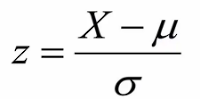

This operation centers all telemetry streams around zero mean and unit variance, ensuring fair mathematical contribution during model convergence.

In [13]:
# =========================================================
# PHASE 5.6 — OUTLIER DETECTION (IQR METHOD)
# =========================================================

# Numerical telemetry columns
numerical_features = X_scaled.columns

# Quartiles
Q1 = X_scaled[numerical_features].quantile(0.25)
Q3 = X_scaled[numerical_features].quantile(0.75)

IQR = Q3 - Q1

# Outlier boundaries
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

# Detect rows containing extreme anomalies
outlier_mask = ((X_scaled < lower_bound) | (X_scaled > upper_bound)).any(axis=1)

print("Total Outlier Records:", outlier_mask.sum())

Total Outlier Records: 0


#### 📝 Phase 5.6 Inference: Geotechnical Extreme States
The IQR analysis identifies statistically extreme telemetry combinations that fall outside expected excavation operating envelopes.

However, in geotechnical engineering, extreme deformation or pore pressure spikes may represent genuine near-collapse conditions rather than sensor corruption.

Therefore, these observations should be reviewed cautiously before deletion, as removing them may unintentionally eliminate critical failure-state learning patterns required for predictive safety modeling.

In [14]:
# =========================================================
# PHASE 5.7 — TRAIN / TEST SEGREGATION
# =========================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("✅ Training Matrix:", X_train.shape)
print("✅ Testing Matrix:", X_test.shape)

✅ Training Matrix: (800, 16)
✅ Testing Matrix: (200, 16)


In [15]:
# =========================================================
# PHASE 5.8 — TARGET BALANCING USING SMOTE
# =========================================================

from imblearn.over_sampling import SMOTE

# Initialize balancing engine
smote = SMOTE(random_state=42)

# Generate synthetic minority excavation states
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("✅ SMOTE Balancing Complete")

print("\n--- CLASS DISTRIBUTION AFTER SMOTE ---")
print(pd.Series(y_train_balanced).value_counts())

✅ SMOTE Balancing Complete

--- CLASS DISTRIBUTION AFTER SMOTE ---
Risk_Level
2    647
1    647
0    647
Name: count, dtype: int64


#### 📝 Phase 5.8 Inference: Eliminating Predictive Bias
EDA revealed that the dataset is heavily dominated by `Risk_Level = 2 (Danger)` excavation states.

Without intervention, Machine Learning models would mathematically bias toward predicting collapse scenarios while underperforming on Safe and Warning classifications.

To mitigate this issue, SMOTE (Synthetic Minority Over-sampling Technique) was deployed to synthetically generate minority-state excavation profiles, thereby equalizing class representation before model training.

In [16]:
# =========================================================
# PHASE 5.9 — FINALIZED ML DATASET EXPORT
# =========================================================

# Export processed feature matrix
processed_dataset = X_scaled.copy()

processed_dataset[TARGET_VAR] = y.values

processed_dataset.to_csv(
    "processed_excavation_risk_dataset.csv",
    index=False
)

print("✅ Final ML-Ready Dataset Exported Successfully")

✅ Final ML-Ready Dataset Exported Successfully
